This is the fintuning codes of Blip-2 model.
I used one A100GPU form lilghtning AI for running the code and used 50 image for the training.

In [ ]:
!pip install git+https://github.com/huggingface/transformers.git@main
!pip install -q datasets
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

  Cloning https://github.com/huggingface/transformers.git (to revision main) to /tmp/pip-req-build-ag8jtskf
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-ag8jtskf

  Resolved https://github.com/huggingface/transformers.git to commit 481a95781404e48b1c80940be17e8279dec82fe8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from datasets import load_dataset

dataset = load_dataset("diffusers/pokemon-gpt4-captions", split = "train")

In [ ]:
import torch

if torch.cuda.is_available():
    print("CUDA is available!")
else:
    print("CUDA is not available.")


CUDA is available!


In [ ]:
import random
def randomize_dataset(dataset, seed):
  """Randomizes the order of examples in a dataset while fixing the seed.

  Args:
    dataset: A Hugging Face Dataset object.
    seed: An integer to set the random seed for reproducibility.

  Returns:
    A new Dataset object with the order of examples randomized.
  """

  # Set the random seed for consistent shuffling
  random.seed(seed)

  # Create a shuffled list of indices
  shuffled_indices = list(range(len(dataset)))
  random.shuffle(shuffled_indices)

  # Reorder the dataset using the shuffled indices
  return dataset.select(shuffled_indices)


In [ ]:
lagbe = randomize_dataset(dataset, 42)

In [ ]:
# Lagbe
# from torch.utils.data import random_split
import torch
import random
random.seed(42)

r = len(lagbe)
dataset_size = int(0.8 * r)
val_size = test_size = int(0.1 * r)
val_size = r - (dataset_size + val_size + val_size ) + val_size

from torch.utils.data import Subset

# Define the indices for each dataset
indices_1 = range(0, dataset_size)
indices_2 = range(dataset_size, dataset_size + val_size)
indices_3 = range(dataset_size + val_size, dataset_size + val_size + test_size)

dataset = Subset(lagbe, indices_1)
validition_dataset = Subset(lagbe, indices_2)
testing_dataset = Subset(lagbe, indices_3)

In [ ]:
def Caption(model, processor, image):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    inputs = processor(images=image,return_tensors="pt").to(device)
    generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=50)
    generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return generated_caption

In [ ]:
#@title bleu_scorer.py
import copy
import sys, math, re
from collections import defaultdict

def precook(s, n=4, out=False):
    """Takes a string as input and returns an object that can be given to
    either cook_refs or cook_test. This is optional: cook_refs and cook_test
    can take string arguments as well."""
    words = s.split()
    counts = defaultdict(int)
    for k in range(1,n+1):
        for i in range(len(words)-k+1):
            ngram = tuple(words[i:i+k])
            counts[ngram] += 1
    return (len(words), counts)

def cook_refs(refs, eff=None, n=4): ## lhuang: oracle will call with "average"
    '''Takes a list of reference sentences for a single segment
    and returns an object that encapsulates everything that BLEU
    needs to know about them.'''

    reflen = []
    maxcounts = {}
    for ref in refs:
        rl, counts = precook(ref, n)
        reflen.append(rl)
        for (ngram,count) in counts.items():
            maxcounts[ngram] = max(maxcounts.get(ngram,0), count)

    # Calculate effective reference sentence length.
    if eff == "shortest":
        reflen = min(reflen)
    elif eff == "average":
        reflen = float(sum(reflen))/len(reflen)

    ## lhuang: N.B.: leave reflen computaiton to the very end!!

    ## lhuang: N.B.: in case of "closest", keep a list of reflens!! (bad design)

    return (reflen, maxcounts)

def cook_test(test, ref_info, eff=None, n=4):
    reflen, refmaxcounts = ref_info
    '''Takes a test sentence and returns an object that
    encapsulates everything that BLEU needs to know about it.'''

    testlen, counts = precook(test, n, True)

    result = {}

    # Calculate effective reference sentence length.

    if eff == "closest":
        result["reflen"] = min((abs(l-testlen), l) for l in reflen)[1]
    else: ## i.e., "average" or "shortest" or None
        result["reflen"] = reflen

    result["testlen"] = testlen

    result["guess"] = [max(0,testlen-k+1) for k in range(1,n+1)]

    result['correct'] = [0]*n
    for (ngram, count) in counts.items():
        result["correct"][len(ngram)-1] += min(refmaxcounts.get(ngram,0), count)

    return result

class BleuScorer(object):
    """Bleu scorer.
    """

    __slots__ = "n", "crefs", "ctest", "_score", "_ratio", "_testlen", "_reflen", "special_reflen"
    # special_reflen is used in oracle (proportional effective ref len for a node).

    def copy(self):
        ''' copy the refs.'''
        new = BleuScorer(n=self.n)
        new.ctest = copy.copy(self.ctest)
        new.crefs = copy.copy(self.crefs)
        new._score = None
        return new

    def __init__(self, test=None, refs=None, n=4, special_reflen=None):
        ''' singular instance '''

        self.n = n
        self.crefs = []
        self.ctest = []
        self.cook_append(test, refs)
        self.special_reflen = special_reflen

    def cook_append(self, test, refs):
        '''called by constructor and __iadd__ to avoid creating new instances.'''

        if refs is not None:
            self.crefs.append(cook_refs(refs))
            if test is not None:
                cooked_test = cook_test(test, self.crefs[-1])
                self.ctest.append(cooked_test) ## N.B.: -1
            else:
                self.ctest.append(None) # lens of crefs and ctest have to match

        self._score = None ## need to recompute

    def ratio(self, option=None):
        self.compute_score(option=option)
        return self._ratio

    def score_ratio(self, option=None):
        '''return (bleu, len_ratio) pair'''
        return (self.fscore(option=option), self.ratio(option=option))

    def score_ratio_str(self, option=None):
        return "%.4f (%.2f)" % self.score_ratio(option)

    def reflen(self, option=None):
        self.compute_score(option=option)
        return self._reflen

    def testlen(self, option=None):
        self.compute_score(option=option)
        return self._testlen

    def retest(self, new_test):
        if type(new_test) is str:
            new_test = [new_test]
        assert len(new_test) == len(self.crefs), new_test
        self.ctest = []
        for t, rs in zip(new_test, self.crefs):
            self.ctest.append(cook_test(t, rs))
        self._score = None

        return self

    def rescore(self, new_test):
        ''' replace test(s) with new test(s), and returns the new score.'''

        return self.retest(new_test).compute_score()

    def size(self):
        assert len(self.crefs) == len(self.ctest), "refs/test mismatch! %d<>%d" % (len(self.crefs), len(self.ctest))
        return len(self.crefs)

    def __iadd__(self, other):
        '''add an instance (e.g., from another sentence).'''

        if type(other) is tuple:
            ## avoid creating new BleuScorer instances
            self.cook_append(other[0], other[1])
        else:
            assert self.compatible(other), "incompatible BLEUs."
            self.ctest.extend(other.ctest)
            self.crefs.extend(other.crefs)
            self._score = None ## need to recompute

        return self

    def compatible(self, other):
        return isinstance(other, BleuScorer) and self.n == other.n

    def single_reflen(self, option="average"):
        return self._single_reflen(self.crefs[0][0], option)

    def _single_reflen(self, reflens, option=None, testlen=None):

        if option == "shortest":
            reflen = min(reflens)
        elif option == "average":
            reflen = float(sum(reflens))/len(reflens)
        elif option == "closest":
            reflen = min((abs(l-testlen), l) for l in reflens)[1]
        else:
            assert False, "unsupported reflen option %s" % option

        return reflen

    def recompute_score(self, option=None, verbose=0):
        self._score = None
        return self.compute_score(option, verbose)

    def compute_score(self, option=None, verbose=0):
        n = self.n
        small = 1e-9
        tiny = 1e-15 ## so that if guess is 0 still return 0
        bleu_list = [[] for _ in range(n)]

        if self._score is not None:
            return self._score

        if option is None:
            option = "average" if len(self.crefs) == 1 else "closest"

        self._testlen = 0
        self._reflen = 0
        totalcomps = {'testlen':0, 'reflen':0, 'guess':[0]*n, 'correct':[0]*n}

        # for each sentence
        for comps in self.ctest:
            testlen = comps['testlen']
            self._testlen += testlen

            if self.special_reflen is None: ## need computation
                reflen = self._single_reflen(comps['reflen'], option, testlen)
            else:
                reflen = self.special_reflen

            self._reflen += reflen

            for key in ['guess','correct']:
                for k in range(n):
                    totalcomps[key][k] += comps[key][k]

            # append per image bleu score
            bleu = 1.
            for k in range(n):
                bleu *= (float(comps['correct'][k]) + tiny) \
                        /(float(comps['guess'][k]) + small)
                bleu_list[k].append(bleu ** (1./(k+1)))
            ratio = (testlen + tiny) / (reflen + small) ## N.B.: avoid zero division
            if ratio < 1:
                for k in range(n):
                    bleu_list[k][-1] *= math.exp(1 - 1/ratio)

            # if verbose > 1:
            #     print (comps, reflen)

        totalcomps['reflen'] = self._reflen
        totalcomps['testlen'] = self._testlen

        bleus = []
        bleu = 1.
        for k in range(n):
            bleu *= float(totalcomps['correct'][k] + tiny) \
                    / (totalcomps['guess'][k] + small)
            bleus.append(bleu ** (1./(k+1)))
        ratio = (self._testlen + tiny) / (self._reflen + small) ## N.B.: avoid zero division
        if ratio < 1:
            for k in range(n):
                bleus[k] *= math.exp(1 - 1/ratio)

        # if verbose > 0:
        #     print (totalcomps)
        #     print( "ratio:", ratio)

        self._score = bleus
        return self._score, bleu_list

In [ ]:
#@title bleu.py

class Bleu:
    def __init__(self, n=4):
        # default compute Blue score up to 4
        self._n = n
        self._hypo_for_image = {}
        self.ref_for_image = {}

    def compute_score(self, gts, res):

        assert(gts.keys() == res.keys())
        imgIds = gts.keys()

        bleu_scorer = BleuScorer(n=self._n)
        for id in imgIds:
            hypo = res[id]
            ref = gts[id]

            # Sanity check.
            assert(type(hypo) is list)
            assert(len(hypo) == 1)
            assert(type(ref) is list)
            assert(len(ref) >= 1)

            bleu_scorer += (hypo[0], ref)

        #score, scores = bleu_scorer.compute_score(option='shortest')
        score, scores = bleu_scorer.compute_score(option='closest', verbose=1)
        #score, scores = bleu_scorer.compute_score(option='average', verbose=1)

        # return (bleu, bleu_info)
        return score, scores

    def method(self):
        return "Bleu"

In [ ]:
#@title cider_scorer.py

#!/usr/bin/env python
# Tsung-Yi Lin <tl483@cornell.edu>
# Ramakrishna Vedantam <vrama91@vt.edu>

import copy
from collections import defaultdict
import numpy as np
import pdb
import math

def cider_precook(s, n=4, out=False):
    """
    Takes a string as input and returns an object that can be given to
    either cook_refs or cook_test. This is optional: cook_refs and cook_test
    can take string arguments as well.
    :param s: string : sentence to be converted into ngrams
    :param n: int    : number of ngrams for which representation is calculated
    :return: term frequency vector for occuring ngrams
    """
    words = s.split()
    counts = defaultdict(int)
    for k in range(1,n+1):
        for i in range(len(words)-k+1):
            ngram = tuple(words[i:i+k])
            counts[ngram] += 1
    return counts

def cider_cook_refs(refs, n=4): ## lhuang: oracle will call with "average"
    '''Takes a list of reference sentences for a single segment
    and returns an object that encapsulates everything that BLEU
    needs to know about them.
    :param refs: list of string : reference sentences for some image
    :param n: int : number of ngrams for which (ngram) representation is calculated
    :return: result (list of dict)
    '''
    return [cider_precook(ref, n) for ref in refs]

def cider_cook_test(test, n=4):
    '''Takes a test sentence and returns an object that
    encapsulates everything that BLEU needs to know about it.
    :param test: list of string : hypothesis sentence for some image
    :param n: int : number of ngrams for which (ngram) representation is calculated
    :return: result (dict)
    '''
    return cider_precook(test, n, True)

class CiderScorer(object):
    """CIDEr scorer.
    """

    def copy(self):
        ''' copy the refs.'''
        new = CiderScorer(n=self.n)
        new.ctest = copy.copy(self.ctest)
        new.crefs = copy.copy(self.crefs)
        return new

    def __init__(self, test=None, refs=None, n=4, sigma=6.0):
        ''' singular instance '''
        self.n = n
        self.sigma = sigma
        self.crefs = []
        self.ctest = []
        self.document_frequency = defaultdict(float)
        self.cook_append(test, refs)
        self.ref_len = None

    def cook_append(self, test, refs):
        '''called by constructor and __iadd__ to avoid creating new instances.'''

        if refs is not None:
            self.crefs.append(cider_cook_refs(refs))
            if test is not None:
                self.ctest.append(cider_cook_test(test)) ## N.B.: -1
            else:
                self.ctest.append(None) # lens of crefs and ctest have to match

    def size(self):
        assert len(self.crefs) == len(self.ctest), "refs/test mismatch! %d<>%d" % (len(self.crefs), len(self.ctest))
        return len(self.crefs)

    def __iadd__(self, other):
        '''add an instance (e.g., from another sentence).'''

        if type(other) is tuple:
            ## avoid creating new CiderScorer instances
            self.cook_append(other[0], other[1])
        else:
            self.ctest.extend(other.ctest)
            self.crefs.extend(other.crefs)

        return self
    def compute_doc_freq(self):
        '''
        Compute term frequency for reference data.
        This will be used to compute idf (inverse document frequency later)
        The term frequency is stored in the object
        :return: None
        '''
        for refs in self.crefs:
            # refs, k ref captions of one image
            for ngram in set([ngram for ref in refs for (ngram,count) in ref.items()]):
                self.document_frequency[ngram] += 1
            # maxcounts[ngram] = max(maxcounts.get(ngram,0), count)

    def compute_cider(self):
        def counts2vec(cnts):
            """
            Function maps counts of ngram to vector of tfidf weights.
            The function returns vec, an array of dictionary that store mapping of n-gram and tf-idf weights.
            The n-th entry of array denotes length of n-grams.
            :param cnts:
            :return: vec (array of dict), norm (array of float), length (int)
            """
            vec = [defaultdict(float) for _ in range(self.n)]
            length = 0
            norm = [0.0 for _ in range(self.n)]
            for (ngram,term_freq) in cnts.items():
                # give word count 1 if it doesn't appear in reference corpus
                df = np.log(max(1.0, self.document_frequency[ngram]))
                # ngram index
                n = len(ngram)-1
                # tf (term_freq) * idf (precomputed idf) for n-grams
                vec[n][ngram] = float(term_freq)*(self.ref_len - df)
                # compute norm for the vector.  the norm will be used for computing similarity
                norm[n] += pow(vec[n][ngram], 2)

                if n == 1:
                    length += term_freq
            norm = [np.sqrt(n) for n in norm]
            return vec, norm, length

        def sim(vec_hyp, vec_ref, norm_hyp, norm_ref, length_hyp, length_ref):
            '''
            Compute the cosine similarity of two vectors.
            :param vec_hyp: array of dictionary for vector corresponding to hypothesis
            :param vec_ref: array of dictionary for vector corresponding to reference
            :param norm_hyp: array of float for vector corresponding to hypothesis
            :param norm_ref: array of float for vector corresponding to reference
            :param length_hyp: int containing length of hypothesis
            :param length_ref: int containing length of reference
            :return: array of score for each n-grams cosine similarity
            '''
            delta = float(length_hyp - length_ref)
            # measure consine similarity
            val = np.array([0.0 for _ in range(self.n)])
            for n in range(self.n):
                # ngram
                for (ngram,count) in vec_hyp[n].items():
                    # vrama91 : added clipping
                    val[n] += min(vec_hyp[n][ngram], vec_ref[n][ngram]) * vec_ref[n][ngram]

                if (norm_hyp[n] != 0) and (norm_ref[n] != 0):
                    val[n] /= (norm_hyp[n]*norm_ref[n])

                assert(not math.isnan(val[n]))
                # vrama91: added a length based gaussian penalty
                val[n] *= np.e**(-(delta**2)/(2*self.sigma**2))
            return val

        # compute log reference length
        self.ref_len = np.log(float(len(self.crefs)))

        scores = []
        for test, refs in zip(self.ctest, self.crefs):
            # compute vector for test captions
            vec, norm, length = counts2vec(test)
            # compute vector for ref captions
            score = np.array([0.0 for _ in range(self.n)])
            for ref in refs:
                vec_ref, norm_ref, length_ref = counts2vec(ref)
                score += sim(vec, vec_ref, norm, norm_ref, length, length_ref)
            # change by vrama91 - mean of ngram scores, instead of sum
            score_avg = np.mean(score)
            # divide by number of references
            score_avg /= len(refs)
            # multiply score by 10
            score_avg *= 10.0
            # append score of an image to the score list
            scores.append(score_avg)
        return scores

    def compute_score(self, option=None, verbose=0):
        # compute idf
        self.compute_doc_freq()
        # assert to check document frequency
        assert(len(self.ctest) >= max(self.document_frequency.values()))
        # compute cider score
        score = self.compute_cider()
        # debug
        # print score
        return np.mean(np.array(score)), np.array(score)

In [ ]:
#@title cider.py
# Filename: cider.py
#
# Description: Describes the class to compute the CIDEr (Consensus-Based Image Description Evaluation) Metric
#               by Vedantam, Zitnick, and Parikh (http://arxiv.org/abs/1411.5726)
#
# Creation Date: Sun Feb  8 14:16:54 2015
#
# Authors: Ramakrishna Vedantam <vrama91@vt.edu> and Tsung-Yi Lin <tl483@cornell.edu>

# from cider_scorer import CiderScorer
import pdb

class Cider:
    """
    Main Class to compute the CIDEr metric

    """
    def __init__(self, test=None, refs=None, n=4, sigma=6.0):
        # set cider to sum over 1 to 4-grams
        self._n = n
        # set the standard deviation parameter for gaussian penalty
        self._sigma = sigma

    def compute_score(self, gts, res):
        """
        Main function to compute CIDEr score
        :param  hypo_for_image (dict) : dictionary with key <image> and value <tokenized hypothesis / candidate sentence>
                ref_for_image (dict)  : dictionary with key <image> and value <tokenized reference sentence>
        :return: cider (float) : computed CIDEr score for the corpus
        """

        assert(gts.keys() == res.keys())
        imgIds = gts.keys()

        cider_scorer = CiderScorer(n=self._n, sigma=self._sigma)

        for id in imgIds:
            hypo = res[id]
            ref = gts[id]

            # Sanity check.
            assert(type(hypo) is list)
            assert(len(hypo) == 1)
            assert(type(ref) is list)
            assert(len(ref) > 0)

            cider_scorer += (hypo[0], ref)

        (score, scores) = cider_scorer.compute_score()

        return score, scores

    def method(self):
        return "CIDEr"

In [ ]:
!git clone https://github.com/tylin/coco-caption

fatal: destination path 'coco-caption' already exists and is not an empty directory.


⚡️ Tip	Connect GitHub to Studios: https://lightning.ai:443/kazijacy/home?settings=integrations



In [ ]:
#@title get_the_scores Method
import sys

def get_the_scores(reference, candidate):
    reference = {'image_id': ['2sfdbs4646'], 'text': reference}
    candidate = {'image_id': ['2sfdbs4646'], 'text': candidate}

    # Calculate CIDEr score
    cider_calculator = Cider()
    cider_score, cider_scores = cider_calculator.compute_score(reference, candidate)

    # Calculate BLEU score
    bleu_calculator = Bleu()
    bleu_score, bleu_scores = bleu_calculator.compute_score(reference, candidate)

    # Append Rouge module path to sys.path
    sys.path.append('/teamspace/studios/this_studio/coco-caption/pycocoevalcap/rouge')
    from rouge import Rouge
    rouge_calculator = Rouge()
    rouge_score, rouge_scores = rouge_calculator.compute_score(reference, candidate)

    # Return scores
    return {
        'CIDEr': {'score': cider_score, 'scores': cider_scores},
        'BLEU': {'score': bleu_score, 'scores': bleu_scores},
        'Rouge': {'score': rouge_score, 'scores': rouge_scores}
    }


In [ ]:
#@title print_the_scores(model, processor, dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
def print_the_scores(model, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  for id in testing_dataset:
    if image_cnt > 50:
      break
    # print ("Image No: ", image_cnt)
    image = id['image']
    text = id['text']
    caption = Caption(model, processor, image)

    references, predictions = [], []
    references.append(text)
    predictions.append(caption)

    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(3, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(3, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(3, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

In [ ]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration
from transformers import AutoTokenizer
import torch
processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")
tokenizer = AutoTokenizer.from_pretrained("Salesforce/blip2-opt-2.7b")

In [ ]:
model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16)
model_b_fine = Blip2ForConditionalGeneration.from_pretrained("sashakunitsyn/vlrm-blip2-opt-2.7b", torch_dtype=torch.float16)
model_large =  Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-6.7b", torch_dtype=torch.float16)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
#@title sentence_by_proxy (model, model_b, model_l, processor, image)
def sentence_by_proxy (processor, image):

  decoder_input_ids = [2]
  inputs = processor(images=image, return_tensors="pt").to(device)
  input_ids = torch.LongTensor([decoder_input_ids]).to(device)

  predicted_ids = []

  # model_large.cuda()
  # print(torch.cuda.memory_allocated())
  # del model_large
  # print(torch.cuda.memory_allocated())



  # with torch.no_grad():
  for i in range(60):
      # model base
      # print ("before base: ", torch.cuda.memory_allocated())
      model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16)
      model.cuda()
      logits_base = ( model( pixel_values=inputs.pixel_values, input_ids=input_ids).logits.detach())[:, -1, :]
      del model
      # print ("Before mid: ", torch.cuda.memory_allocated())

      # model fine
      model_b = Blip2ForConditionalGeneration.from_pretrained("sashakunitsyn/vlrm-blip2-opt-2.7b", torch_dtype=torch.float16)
      model_b.cuda()
      logits_tuned = ( model_b( pixel_values=inputs.pixel_values, input_ids=input_ids).logits.detach())[:, -1, :]
      logits_tuned -= logits_base
      del logits_base
      del model_b

      # print ("Before Big: ", torch.cuda.memory_allocated())
      # model_large
      model_l = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-6.7b", torch_dtype=torch.float16)
      model_l.cuda()
      logits = ( model_l( pixel_values=inputs.pixel_values, input_ids=input_ids).logits.detach())[:, -1, :]
      del model_l

      logits += logits_tuned
      del logits_tuned

      predicted_id = logits.argmax(-1)
      del logits

      if predicted_id.item() != 50118 : # for avoiding <n/>
        predicted_ids.append(predicted_id.item())

      if predicted_id.squeeze() == 50118:
          break

      # add predicted id to decoder_input_ids
      input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)


  sentence = tokenizer.decode(predicted_ids,skip_special_tokens = True)
  return sentence


In [ ]:
#@title print_the_scores_of_proxy(model, model_b, model_l, processor, testing_dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
# !pip install matplotlib
def print_the_scores_of_proxy(processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  for id in testing_dataset:

    if image_cnt > 50:
      break

    print(image_cnt)
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy(processor = processor, image = image)

    references, predictions = [], []
    references.append(text)
    predictions.append(caption)

    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  return {
        'image_bleu_scores': image_bleu_scores,
        'image_cidar_scores': image_cidar_scores,
        'image_rouge_scores': image_rouge_scores
    }

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(3, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(3, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(3, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

In [ ]:
#@title print_the_proxy
import matplotlib.pyplot as plt
def print_the_proxy(my_data) :
  image_bleu_scores = my_data['image_bleu_scores']
  image_cidar_scores = my_data['image_cidar_scores']
  image_rouge_scores = my_data['image_rouge_scores']

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(3, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(3, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(3, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()


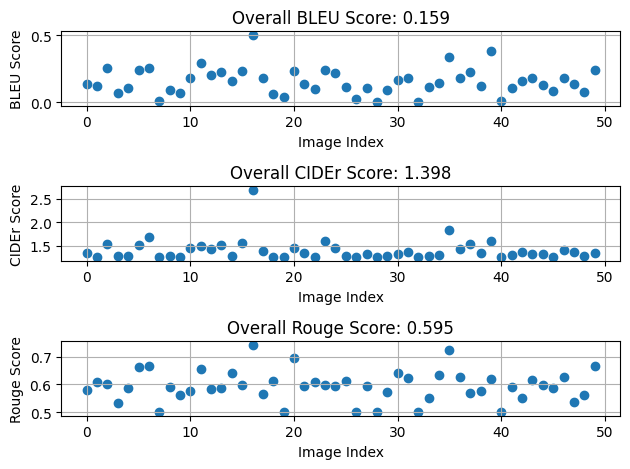

In [ ]:
# Base Model Scores
model.cuda()
print_the_scores(model=model, processor=processor, testing_dataset=testing_dataset)
del model

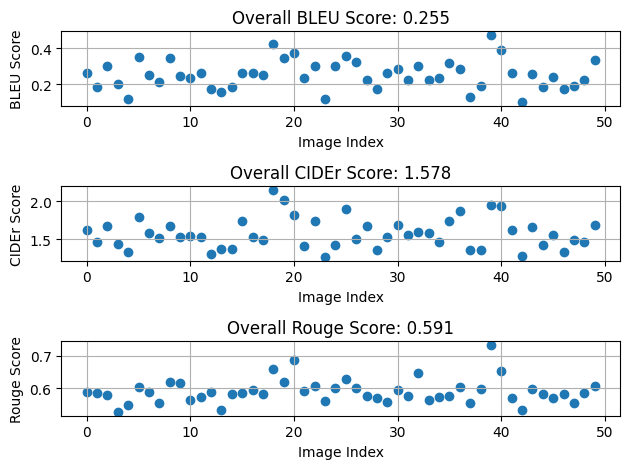

In [ ]:
# Base Fine-Tuned Model Scores
model_b_fine.cuda()
print_the_scores(model=model_b_fine, processor=processor, testing_dataset=testing_dataset)
del model_b_fine

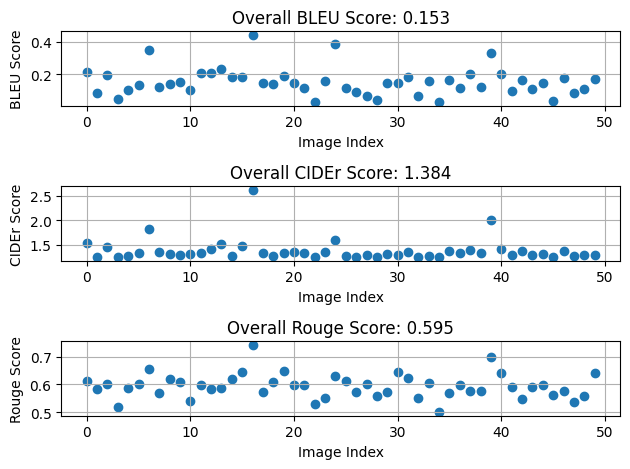

In [ ]:
# Large Model Scores
model_large.cuda()
print_the_scores(model=model_large, processor=processor, testing_dataset=testing_dataset)
del model_large

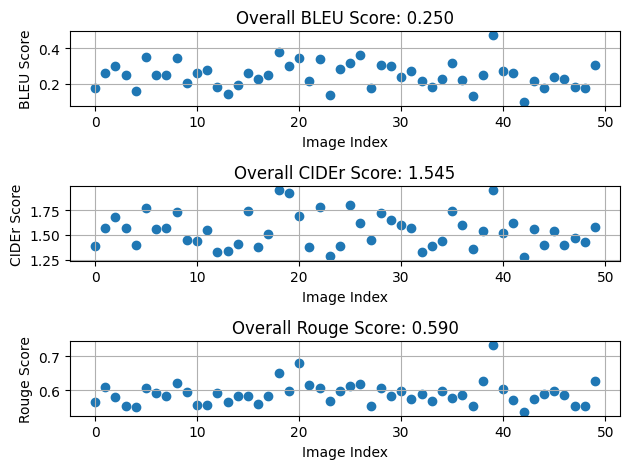

In [ ]:
# Proxy tune score
print_the_proxy(my_data)

In [ ]:
my_data = print_the_scores_of_proxy(processor = processor, testing_dataset = testing_dataset)

In [ ]:
print(torch.cuda.memory_allocated())

8519680


In [ ]:
del model_l

In [ ]:
import torch

def print_cuda_memory_info():
    total_memory = torch.cuda.get_device_properties(0).total_memory
    reserved_memory = torch.cuda.memory_reserved(0)
    allocated_memory = torch.cuda.memory_allocated(0)
    free_memory = reserved_memory - allocated_memory

    print(f"Total memory: {total_memory / (1024**3):.2f} GB")
    print(f"Reserved memory: {reserved_memory / (1024**3):.2f} GB")
    print(f"Allocated memory: {allocated_memory / (1024**3):.2f} GB")
    print(f"Free memory: {free_memory / (1024**3):.2f} GB")

print_cuda_memory_info()


In [ ]:
import logging

logging.getLogger('torch').setLevel(logging.ERROR)
